# training_example

This notebook demonstrates the functionality of the `XGBModelTrainer` class, and how it is instantiated, used for model training, evaluation, and hyperparameter tuning

## Contents
1) Load example data and create a data split and weights for testing

2) Create a configuration file within the notebook that is passed to `XGBModelTrainer`
    - Show default parameters and how a configuration file can also be written directly as a YAML

3) Train a baseline model using the `train()` method

4) Evaluate the baseline model using the `evaluate()` method
    - Show default parameters, and how different plots can be added using the configuration file

5) Create a model with tuned hyperparameters using the `tune()` method
    - Show functionality for using different (_and custom_) scoring functions for tuning

In [114]:
import pandas as pd
import numpy as np
import sys, os
from importlib import reload
import yaml
from pathlib import Path
from dataclasses import asdict

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))
from analysis import plots
import analysis.report
import training.gbm_model_trainer
from training.gbm_model_trainer import XGBModelTrainer 

reload(analysis)
reload(analysis.plots)
reload(analysis.report)
reload(training.gbm_model_trainer)

<module 'training.gbm_model_trainer' from 'c:\\Users\\ASacco\\OneDrive - Plymouth Rock Assurance Corp\\repos\\analysis-tools\\src\\training\\gbm_model_trainer.py'>

## 1. Load example data

In [2]:
df = pd.read_csv("../data/bank-full.csv", delimiter=';')

In [3]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [38]:
# Convert 'y' to numeric for analysis
df["target"] = np.where(df["y"] == "no", 0, 1)

# Add weights to test weight parameter across functions 
df["weights"] = np.abs(np.random.randn(len(df.index))).clip(0.8, 1.0)

# Add an arbitrary data split for testing functions (TVH = 40/30/30)
df["random"] = np.random.uniform(0, 1, len(df.index))
df["split"] = np.where(
    df["random"]  > 0.70, 
    "V",
    np.where(
        df["random"]  > 0.40, 
        "H", 
        "T"
    )
)

# Add weights to test weight parameter across functions 
df["weights"] = np.abs(np.random.randn(len(df.index))).clip(0.4, 1.0)

In [39]:
df["split"].value_counts(dropna=False, normalize=True)

split
T    0.402336
V    0.300391
H    0.297273
Name: proportion, dtype: float64

In [40]:
df.groupby("split")["target"].mean()

split
H    0.120759
T    0.115778
V    0.114866
Name: target, dtype: float64

In [41]:
# Split data; define features and target
train = df.query("split == 'T'").drop(columns=["y", "split"])
test = df.query("split == 'V'").drop(columns=["y", "split"])
holdout = df.query("split == 'H'").drop(columns=["y", "split"])

## 2. Create a configuration file used for training
- Can use example config files in `analysis-tools/examples` or create a config within your notebook and save it locally
- You can also create your config within the notebook (_see below_) or write a YAML file directly in the format used within `analysis-tools/examples`

In [ ]:
# Define your config
reload(training.gbm_model_trainer)
from training.gbm_model_trainer import TrainingConfig, EvaluationConfig, TuningConfig  

full_config = TrainingConfig(
    # Training parameters
    actual_col="target",         # Target variable to predict
    predicted_col="pred_xgb",    # Column to output with predictions
    output_dir="outputs",        # Folder for model outputs: can also be an S3 path (optional, default is "outputs")
    log_file="training.log",     # Name of log file to output to output_dir (optional, default is "training.log")
    model_file="model_obj.json", # Name of model object to output to output_dir (optional, default is "model.json")

    hyperparameters={
        "objective": "binary:logistic", # Objective function: corresponds to the response variable (binary:logistic for logistic regression)
        "n_estimators": 100,
        "max_depth": 3,
        "learning_rate": 0.1,
        "subsample": 0.5,
        "colsample_bytree": 0.5,
        "eval_metric": ["logloss", "auc"], # Multiple metrics can be specified for evaluation
        "scale_pos_weight": 5.0, # Approximate ratio of negative to positive cases in the training set
    },
    output_log=True,      # Should a log be output
    base_margin_col=None, # base_margin column name - similar to an offset for a GLM (optional)
    weight_col="weights", # Column name for weights (optional)

    # Logging for training
    log_eval_period=50,

    # Optional parameters where default is no early stopping: Use if you want to stop training early. Specify the 
    # number of rounds to wait before stopping if no improvement is seen. Also specify the metric to monitor and
    # whether higher or lower values are better.
    early_stopping_rounds=20,
    early_stopping_metric="auc",  # Metric to monitor for early stopping 
    early_stopping_maximize=True, # Higher AUC is better. Switch to False for metrics like logloss where lower is better.

    # Optional parameters: Parameters to control output of evaluation report. No `plots_to_add` are set then model
    # then model evaluation plots will be output be default (i.e., Lorenz Curve, Lift Chart, Crunched Residuals, Heteroskedasticity checks) 
    evaluation=EvaluationConfig(
        report_file="model_analysis.html",
        tabulate_vars=["job", "education", "age"],
        plots_to_add=[ # If 
            {"plot": "gain_curve_with_gini", "title": "Gain Curve / Lorenz Curve"},
            {
                "plot": "partial_gini_plot",
                "title": "Partial Gini (Top 15%)",
                "kwargs": {"top_percent": 15},
            },
            {"plot": "lift_chart", "title": "Lift Chart"},
            {"plot": "crunched_residual_plot", "title": "Crunched Residuals"},
            {
                "plot": "plot_residual_fit",
                "title": "Std and Avg of Normalized Residuals",
                "kwargs": {"residual_type": "normalized"},
            },
        ]
    ),

    # Tuning setup
    tuning=TuningConfig(
        # Search space can be specified by number type with low and high bounds, or as a list with a low and high number
        # Examples for both are shown here
        search_space={
            "max_depth": [3, 6],
            "eta": {"type": "real", "low": 0.01, "high": 0.3}, # Equivalent to [0.01, 0.3]
            "subsample": [0.6, 0.9], # Equivalent to {"type": "real", "low": 0.6, "high": 0.9}
        },
        # If only CV is passed, hyperparameters will be selected using {cv}-fold cross validation on the combined 
        # train and test set without stratification. If `stratified_cv` is passed, {cv}-fold cross validation will
        # be performed with stratification on the variable(s) specified in `stratified_cv`
        cv=3,
        stratified_cv=["loan"],
        n_iter=25, # Number of tuning rounds
        tuning_file="tuning_results.csv",
    )
)

# Output config to YAML
config_output_path = Path("../examples/example_config.yaml")

import yaml
# Write config to YAML file
with config_output_path.open("w") as f:
    yaml.dump(asdict(full_config), f, indent=2)

print(f"Config saved to {config_output_path.resolve()}")

Config saved to C:\Users\ASacco\OneDrive - Plymouth Rock Assurance Corp\repos\analysis-tools\examples\example_config.yaml


### Example of a smaller config that utilizes defaults

In [43]:
slim_config = TrainingConfig(
    # Training parameters
    actual_col="target",         # Target variable to predict
    predicted_col="pred_xgb",    # Column to output with predictions

    hyperparameters={
        "objective": "binary:logistic", # Objective function: corresponds to the response variable (binary:logistic for logistic regression)
        "n_estimators": 250,
        "max_depth": 3,
        "learning_rate": 0.1,
        "subsample": 0.5,
        "colsample_bytree": 0.5,
        # "eval_metric": ["logloss", "auc"] # Multiple metrics can be specified for evaluation
    },
    output_log=True,      # Should a log be output
    weight_col="weights", # Column name for weights (optional)

    # Output default plots - passing report_file since EvaluationConfig must be passed for report to be created
    evaluation=EvaluationConfig(report_file="model_analysis.html"),

    # Use tuning defaults (cv=5, niter=25, stratified_cv = None)
    tuning=TuningConfig(
            search_space={
                "max_depth": [3, 12],
                "colsample_bytree": [0.1, 0.9]
            },
            objective_func="log_loss",
            maximize=False, 
            tuning_file="tuning_results.csv"
        )
)

# Output config to YAML
config_output_path = Path("../examples/example_slim_config.yaml")

import yaml
# Write config to YAML file
with config_output_path.open("w") as f:
    yaml.dump(asdict(slim_config), f, indent=2)

print(f"Config saved to {config_output_path.resolve()}")

Config saved to C:\Users\ASacco\OneDrive - Plymouth Rock Assurance Corp\repos\analysis-tools\examples\example_slim_config.yaml


## 3. Create an instance of XGBModelTrainer for training, evaluation, and tuning

In [115]:
import analysis.report
import analysis.plots  
import analysis.report
from training.gbm_model_trainer import XGBModelTrainer
from analysis.report import ModelAnalysisReport

reload(training.gbm_model_trainer)
reload(analysis.report)
reload(analysis.plots)
reload(analysis.report)

mt_xgboost = XGBModelTrainer(
    config_path="../examples/example_config.yaml",
    train_df=train,
    valid_df=test,
    holdout_df=holdout
)

c:\Users\ASacco\OneDrive - Plymouth Rock Assurance Corp\repos\analysis-tools\src\scoring\scorers.py:109: UserWarning: Scorer not specified: defaulting to mean_squared_error.
  warnings.warn("Scorer not specified: defaulting to mean_squared_error.")


###  Explore configs

In [49]:
mt_xgboost.config

TrainingConfig(actual_col='target', predicted_col='pred_xgb', output_dir='outputs', log_file='training.log', model_file='model_obj.json', hyperparameters={'colsample_bytree': 0.5, 'eval_metric': ['logloss', 'auc'], 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'objective': 'binary:logistic', 'subsample': 0.5}, output_log=True, weight_col='weights', base_margin_col=None, log_eval_period=50, early_stopping_rounds=20, early_stopping_metric='auc', early_stopping_maximize=True, random_state=2025, evaluation=EvaluationConfig(report_file='model_analysis.html', plots_to_add=[{'plot': 'gain_curve_with_gini', 'title': 'Gain Curve / Lorenz Curve'}, {'kwargs': {'top_percent': 15}, 'plot': 'partial_gini_plot', 'title': 'Partial Gini (Top 15%)'}, {'plot': 'lift_chart', 'title': 'Lift Chart'}, {'plot': 'crunched_residual_plot', 'title': 'Crunched Residuals'}, {'kwargs': {'residual_type': 'normalized'}, 'plot': 'plot_residual_fit', 'title': 'Std and Avg of Normalized Residuals'}], tabulat

In [46]:
mt_xgboost.config.tuning

TuningConfig(search_space={'eta': Real(low=0.01, high=0.3, prior='uniform', transform='identity'), 'max_depth': Integer(low=3, high=6, prior='uniform', transform='identity'), 'subsample': Real(low=0.6, high=0.9, prior='uniform', transform='identity')}, n_iter=25, cv=3, stratified_cv=['loan'], maximize=False, objective_func=(<function mean_squared_error at 0x0000020E4061AC00>, 'mean_squared_error', False), tuning_file='tuning_results.csv')

In [47]:
mt_xgboost.config.evaluation

EvaluationConfig(report_file='model_analysis.html', plots_to_add=[{'plot': 'gain_curve_with_gini', 'title': 'Gain Curve / Lorenz Curve'}, {'kwargs': {'top_percent': 15}, 'plot': 'partial_gini_plot', 'title': 'Partial Gini (Top 15%)'}, {'plot': 'lift_chart', 'title': 'Lift Chart'}, {'plot': 'crunched_residual_plot', 'title': 'Crunched Residuals'}, {'kwargs': {'residual_type': 'normalized'}, 'plot': 'plot_residual_fit', 'title': 'Std and Avg of Normalized Residuals'}], tabulate_vars=['job', 'education', 'age'])

### Train baseline model
- `train()` method outputs the model object, the log file, and the configuration file used to the `output_dir`. This allows for later analysis and re-creation of the model 

In [116]:
mt_xgboost.train()

2025-08-04 15:38:26,109 [INFO] ---------------------------------------------------------------------------
2025-08-04 15:38:26,111 [INFO] BEGINNING MODEL TRAINING
2025-08-04 15:38:26,190 [INFO] [0] validation-logloss: 0.92130
2025-08-04 15:38:26,191 [INFO] [0] validation-auc: 0.66143
2025-08-04 15:38:26,320 [INFO] [50] validation-logloss: 0.32410
2025-08-04 15:38:26,321 [INFO] [50] validation-auc: 0.91863
2025-08-04 15:38:26,445 [INFO] Training completed in 0.3338 seconds
2025-08-04 15:38:26,447 [INFO] Model: XGBoost Booster
2025-08-04 15:38:26,448 [INFO] Hyperparameters: {'colsample_bytree': 0.5, 'eval_metric': ['logloss', 'auc'], 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'objective': 'binary:logistic', 'scale_pos_weight': 5.0, 'subsample': 0.5}
2025-08-04 15:38:26,448 [INFO] Training data shape: (18190, 17)
2025-08-04 15:38:26,449 [INFO] Validation data shape: (13581, 17)
2025-08-04 15:38:26,450 [INFO] Used base margin: No
2025-08-04 15:38:26,450 [INFO] Used weights:

NoCredentialsError: Unable to locate credentials

In [85]:
mar = mt_xgboost.evaluate()

2025-08-04 14:06:53,381 [INFO] ---------------------------------------------------------------------------
2025-08-04 14:06:53,383 [INFO] BEGINNING MODEL EVALUATION
2025-08-04 14:06:54,105 [INFO] Added plot: Gain Curve / Lorenz Curve (gain_curve_with_gini)
2025-08-04 14:06:54,547 [INFO] Added plot: Partial Gini (Top 15%) (partial_gini_plot)
c:\Users\ASacco\OneDrive - Plymouth Rock Assurance Corp\repos\analysis-tools\src\analysis\plots.py:642: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  "Total Exposure": g["exposure"].sum(),
c:\Users\ASacco\OneDrive - Plymouth Rock Assurance Corp\repos\analysis-tools\src\analysis\plots.py:642: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. Th

Analysis report generated at outputs\model_analysis.html


,job,weight_sum_T,pred_sum_T,truth_sum_T,prediction_mean_T,truth_mean_T,lr_error_T,weight_sum_V,pred_sum_V,truth_sum_V,prediction_mean_V,truth_mean_V,lr_error_V,weight_sum_H,pred_sum_H,truth_sum_H,prediction_mean_H,truth_mean_H,lr_error_H
0,admin.,1439,213.152,173.443,0.148,0.120,0.814,1051,168.258,120.028,0.160,0.114,0.713,1099,174.500,142.115,0.159,0.129,0.814
1,blue-collar,2737,246.380,207.492,0.090,0.076,0.842,2028,183.471,148.218,0.090,0.073,0.808,1981,173.906,133.781,0.088,0.068,0.769
2,entrepreneur,397,36.383,30.381,0.092,0.077,0.835,305,33.910,32.461,0.111,0.106,0.957,327,33.068,26.093,0.101,0.080,0.789
3,housemaid,334,40.279,29.712,0.121,0.089,0.738,262,30.864,19.328,0.118,0.074,0.626,265,35.501,26.319,0.134,0.099,0.741
4,management,2636,459.925,368.141,0.174,0.140,0.800,1946,353.957,264.671,0.182,0.136,0.748,1979,367.412,273.795,0.186,0.138,0.745
5,retired,633,170.954,135.173,0.270,0.214,0.791,500,141.530,123.281,0.283,0.247,0.871,453,131.938,99.596,0.291,0.220,0.755
6,self-employed,446,59.060,42.912,0.132,0.096,0.727,337,44.145,45.064,0.131,0.134,1.021,306,41.292,42.253,0.135,0.138,1.023
7,services,1151,119.551,97.107,0.104,0.084,0.812,881,94.713,75.964,0.108,0.086,0.802,864,99.237,87.554,0.115,0.101,0.882
8,student,270,96.738,81.709,0.358,0.302,0.845,187,55.873,40.782,0.299,0.218,0.730,196,66.615,68.316,0.341,0.349,1.026
9,technician,2149,299.637,238.207,0.139,0.111,0.795,1591,226.202,163.624,0.142,0.103,0.723,1502,208.749,171.392,0.139,0.114,0.821

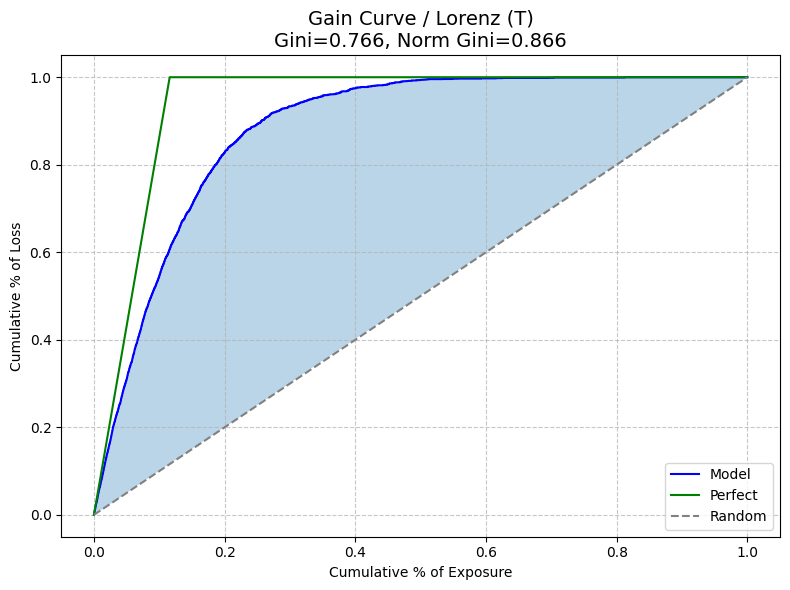
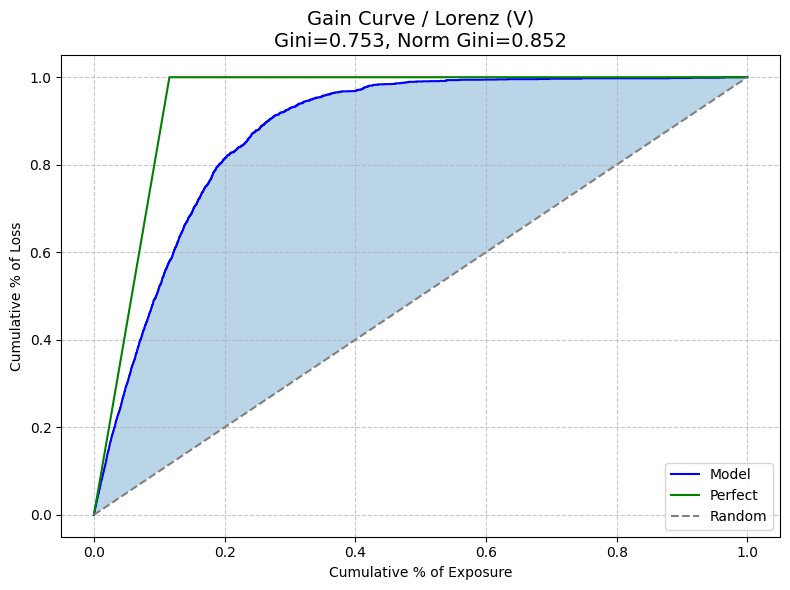
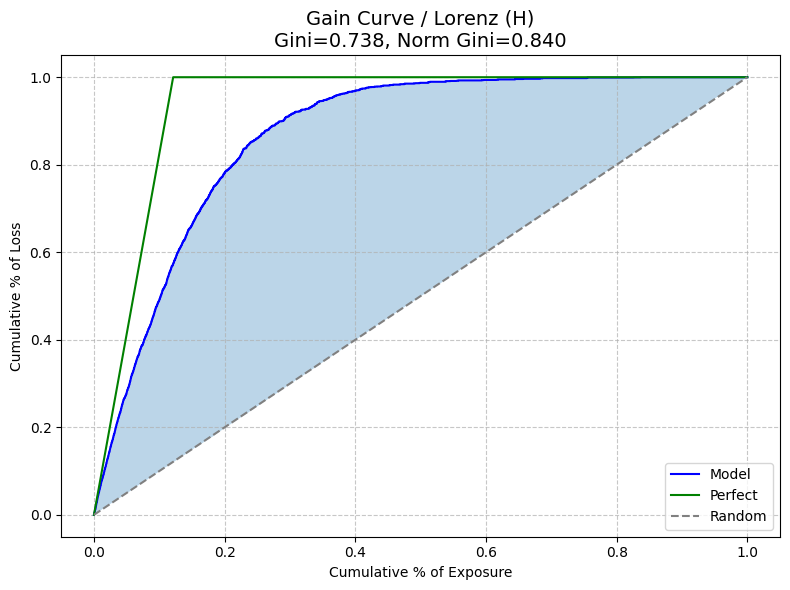
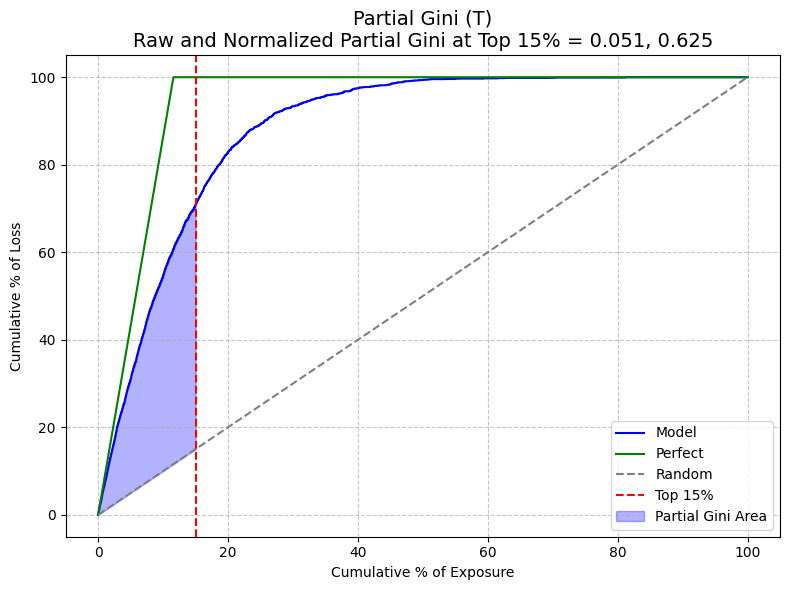
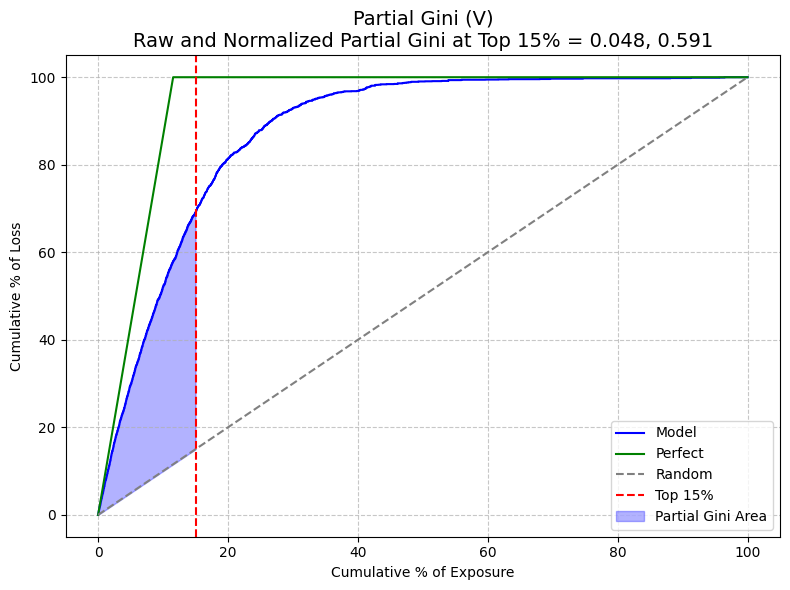
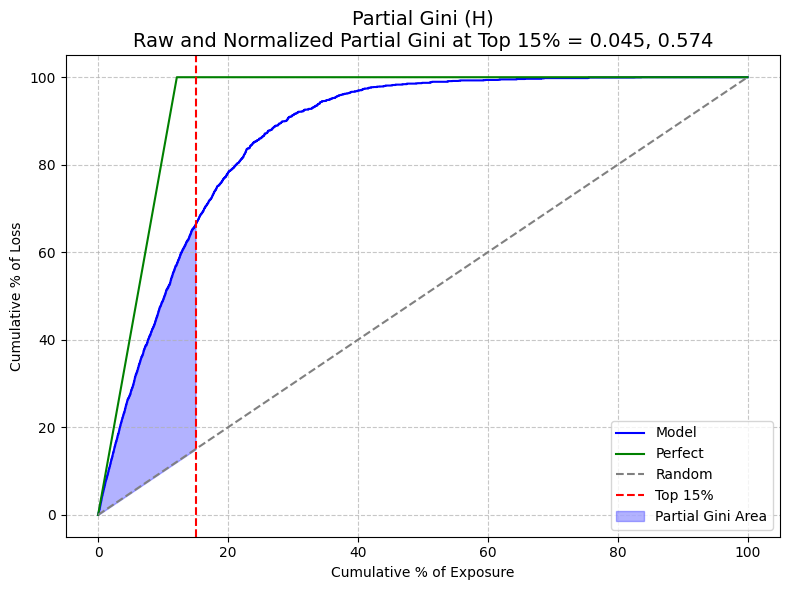
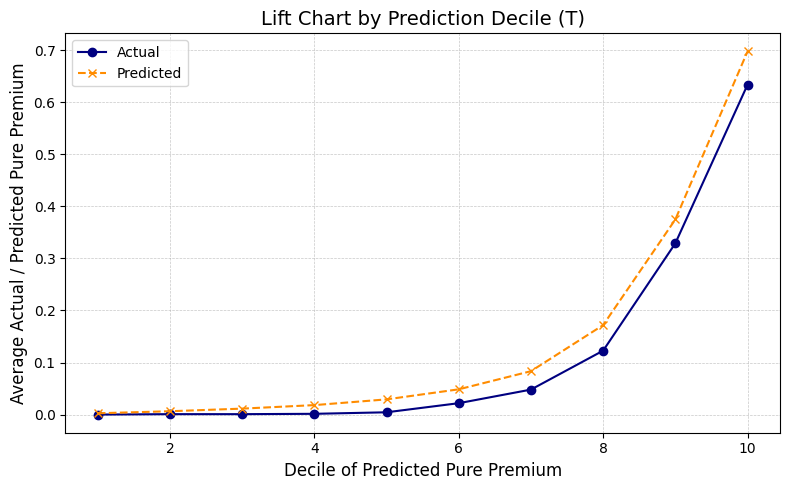
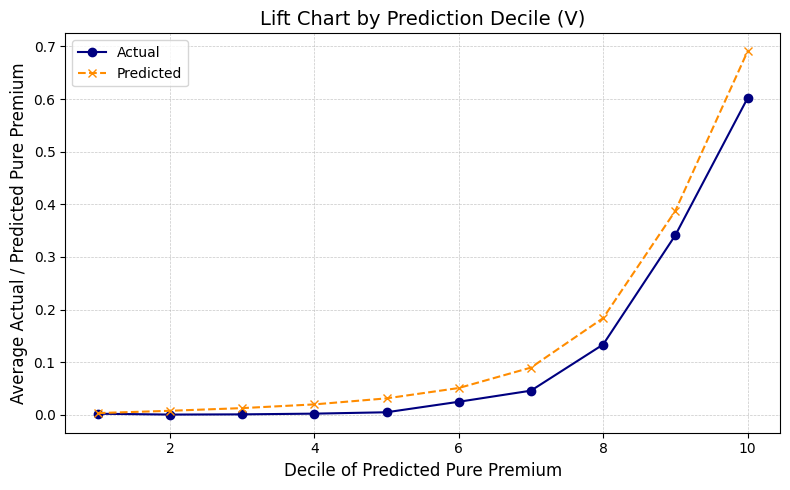
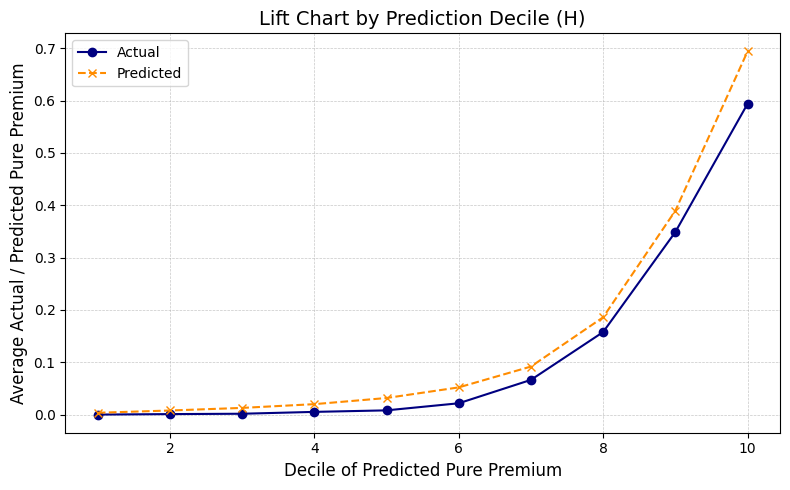
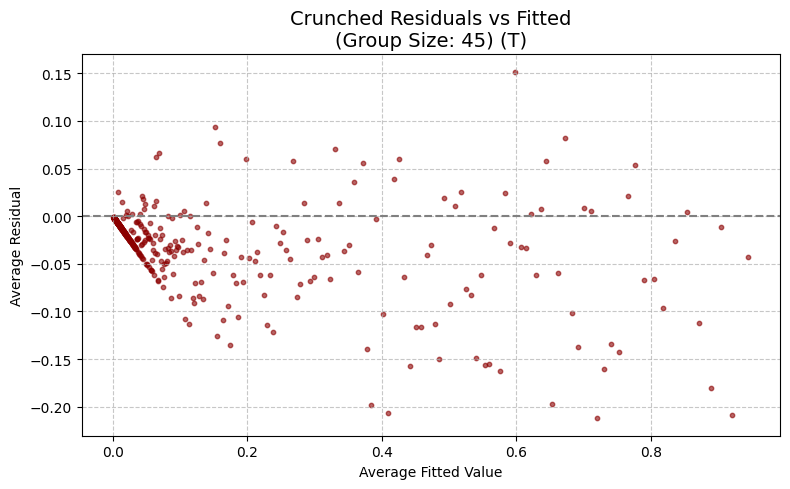
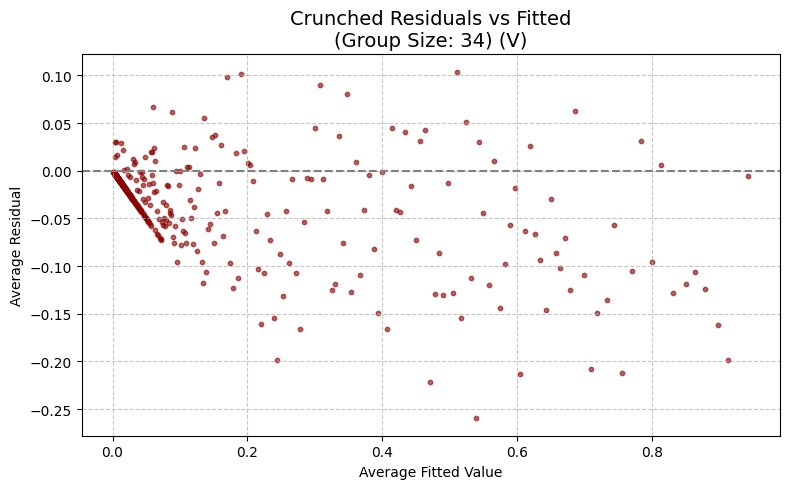
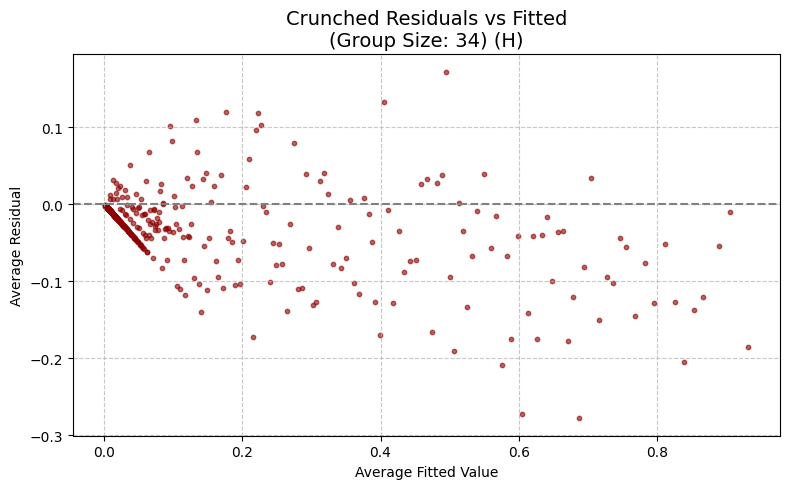
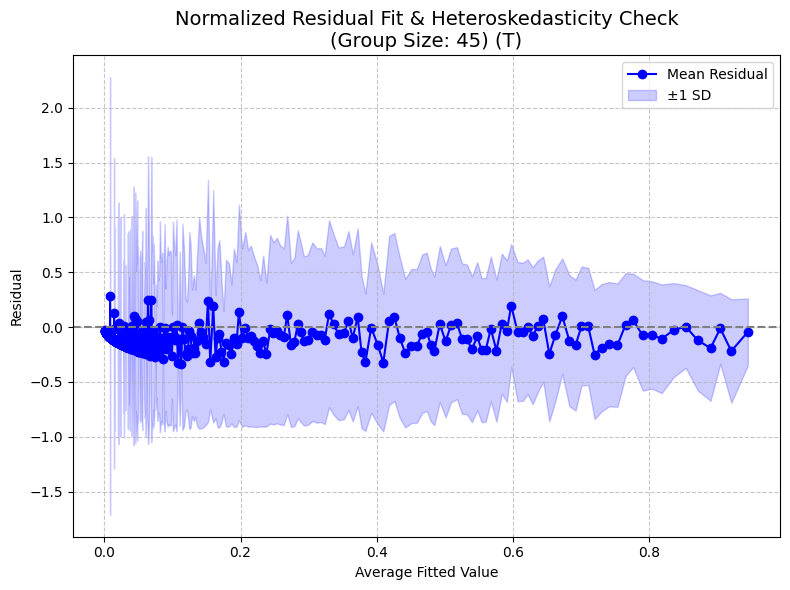
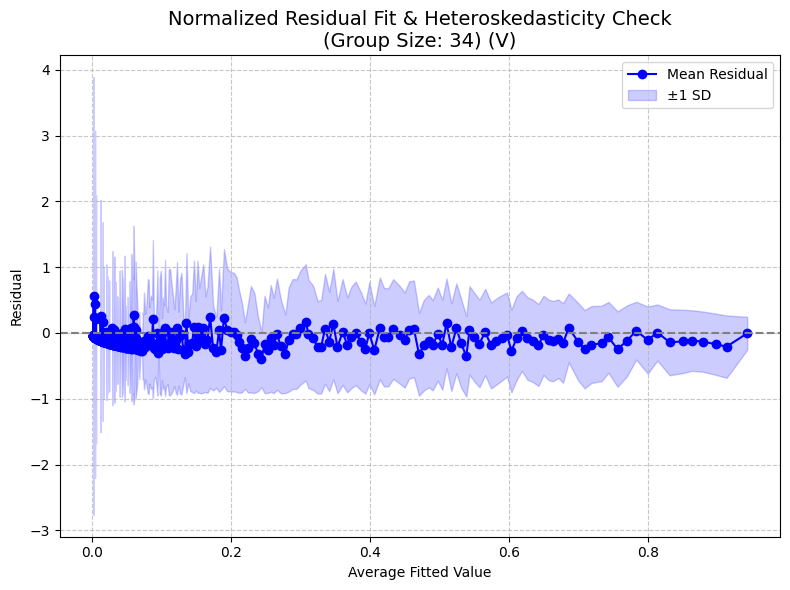
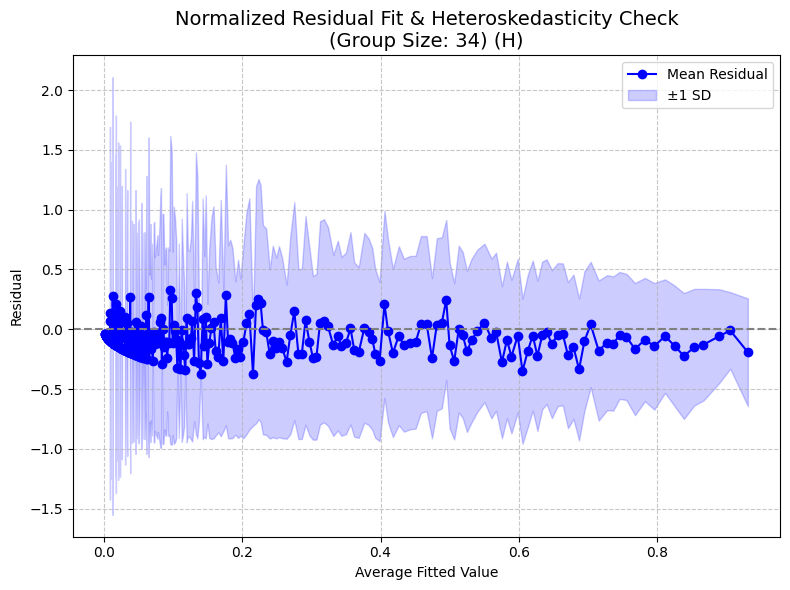

In [106]:
mar

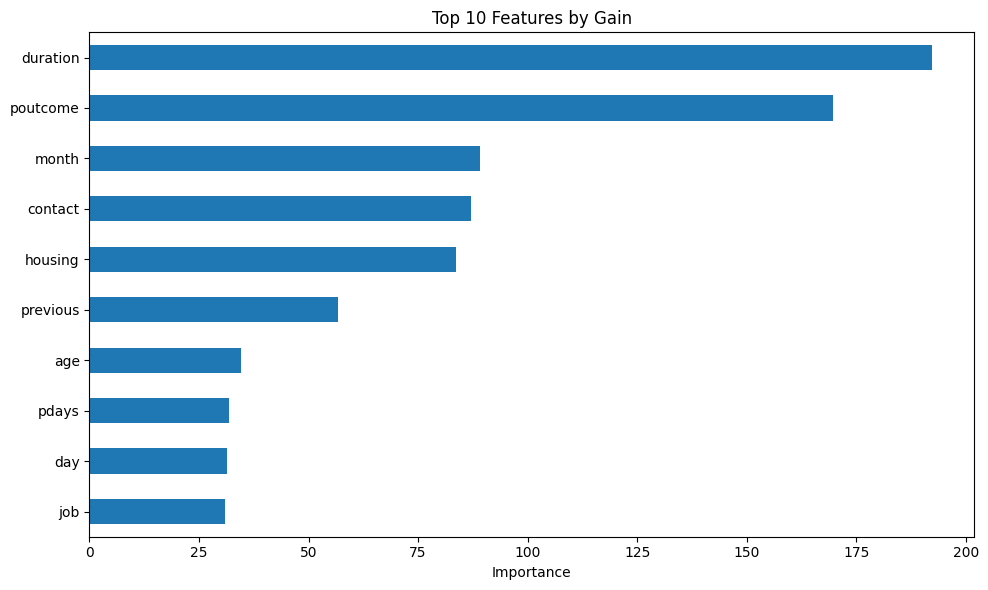

In [90]:
mt_xgboost.plot_feature_importance("gain", top_n=10)

## 4. Create a new tuned model
- Same config as above, but we will tune the model this time

In [100]:
mt_xgboost_tuned = XGBModelTrainer(
    config_path="../examples/example_config.yaml",
    train_df=train,
    valid_df=test,
    holdout_df=holdout
)

# Change output directory for tuned model
mt_xgboost_tuned.config.output_dir = "outputs_tuned"

c:\Users\ASacco\OneDrive - Plymouth Rock Assurance Corp\repos\analysis-tools\src\scoring\scorers.py:109: UserWarning: Scorer not specified: defaulting to mean_squared_error.
  warnings.warn("Scorer not specified: defaulting to mean_squared_error.")


In [101]:
from scoring.scorers import (
    normalized_partial_gini_10, 
    normalized_partial_gini_20,
    normalized_gini,
    gini_mape_70_30_weighted_avg
)

In [102]:
# Maximize partial gini at 20% of the highest predictions
mt_xgboost_tuned.config.tuning.objective_func = normalized_partial_gini_20
mt_xgboost_tuned.config.tuning.maximize = True

# 5 Fold cross validation without stratification
mt_xgboost_tuned.config.tuning.cv = 5
mt_xgboost_tuned.config.tuning.stratified_cv = None

# Number of tuning iterations
mt_xgboost_tuned.config.tuning.n_iter = 50

# Output file
mt_xgboost_tuned.config.tuning.tuning_file = "tuning_results.csv"

tuning_df = mt_xgboost_tuned.tune()

[I 2025-08-04 14:20:33,219] A new study created in memory with name: no-name-db3a42f5-4fbf-4612-996e-7c3338ff43d0
[I 2025-08-04 14:20:34,576] Trial 0 finished with value: 0.6542050530647667 and parameters: {'eta': 0.04929156746660892, 'max_depth': 6, 'subsample': 0.8797816919659507}. Best is trial 0 with value: 0.6542050530647667.
[I 2025-08-04 14:20:35,629] Trial 1 finished with value: 0.6496010672253009 and parameters: {'eta': 0.13921476757380258, 'max_depth': 4, 'subsample': 0.6772789305903477}. Best is trial 0 with value: 0.6542050530647667.
[I 2025-08-04 14:20:36,768] Trial 2 finished with value: 0.6520687102852805 and parameters: {'eta': 0.20063659978660092, 'max_depth': 4, 'subsample': 0.8892715257750172}. Best is trial 0 with value: 0.6542050530647667.
[I 2025-08-04 14:20:37,865] Trial 3 finished with value: 0.6494808574520061 and parameters: {'eta': 0.2422854977121376, 'max_depth': 4, 'subsample': 0.8403174259775985}. Best is trial 0 with value: 0.6542050530647667.
[I 2025-08-

In [105]:
mar_tuned = mt_xgboost_tuned.evaluate()

2025-08-04 14:29:21,279 [INFO] ---------------------------------------------------------------------------
2025-08-04 14:29:21,281 [INFO] BEGINNING MODEL EVALUATION
2025-08-04 14:29:21,986 [INFO] Added plot: Gain Curve / Lorenz Curve (gain_curve_with_gini)
2025-08-04 14:29:22,460 [INFO] Added plot: Partial Gini (Top 15%) (partial_gini_plot)
c:\Users\ASacco\OneDrive - Plymouth Rock Assurance Corp\repos\analysis-tools\src\analysis\plots.py:642: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  "Total Exposure": g["exposure"].sum(),
c:\Users\ASacco\OneDrive - Plymouth Rock Assurance Corp\repos\analysis-tools\src\analysis\plots.py:642: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. Th

Analysis report generated at outputs_tuned\model_analysis.html


In [104]:
tuning_df.head()

,number,value,datetime_start,datetime_complete,duration,params_eta,params_max_depth,params_subsample,state
32,32,0.655853,2025-08-04 14:21:28.219049,2025-08-04 14:21:29.639595,0 days 00:00:01.420546,0.067114,5,0.824811,COMPLETE
16,16,0.655804,2025-08-04 14:20:56.244777,2025-08-04 14:20:58.128015,0 days 00:00:01.883238,0.195508,5,0.809973,COMPLETE
31,31,0.655444,2025-08-04 14:21:26.796702,2025-08-04 14:21:28.217235,0 days 00:00:01.420533,0.060878,5,0.827906,COMPLETE
33,33,0.655404,2025-08-04 14:21:29.641274,2025-08-04 14:21:31.015148,0 days 00:00:01.373874,0.061026,5,0.864531,COMPLETE
45,45,0.655057,2025-08-04 14:21:46.952171,2025-08-04 14:21:48.640298,0 days 00:00:01.688127,0.027613,5,0.830181,COMPLETE
